In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('NASI.csv')

# Identify misclassified rows
misclassified = df[df['category'] != df['orig_category']]

# Save misclassified instances for further analysis
misclassified.to_csv('misclassified.csv', index=False)

print(f"Total Misclassified Instances: {len(misclassified)}")


Total Misclassified Instances: 2318


In [3]:
# Count misclassifications by true vs. predicted category
misclass_counts = misclassified.groupby(['orig_category', 'category']).size().reset_index(name='count')

# Sort by the most frequent misclassifications
misclass_counts = misclass_counts.sort_values(by='count', ascending=False)
print(misclass_counts)


   orig_category category  count
17            C4       C5    463
21            C5       C3    309
7             C2       C5    260
27            C6       C5    193
22            C5       C4    174
12            C3       C5    154
5             C2       C3    143
16            C4       C3    141
6             C2       C4    107
11            C3       C4     70
26            C6       C4     64
19            C5       C1     44
25            C6       C3     33
18            C4       C6     31
0             C1       C3     19
14            C4       C1     19
2             C1       C5     17
4             C2       C1     11
20            C5       C2     10
13            C3       C6      9
8             C2       C6      9
23            C5       C6      9
24            C6       C1      8
1             C1       C4      7
9             C3       C1      6
15            C4       C2      4
10            C3       C2      2
3             C1       C6      2


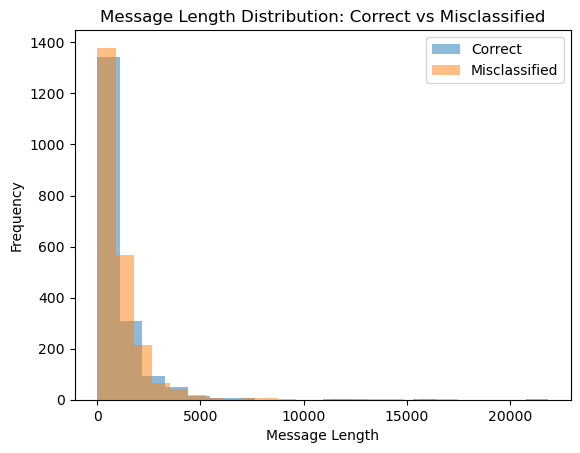

In [4]:
# Add a message length column
df['text_length'] = df['text'].str.len()

# Compare length distributions for misclassified vs correctly classified texts
correct = df[df['category'] == df['orig_category']]['text_length']
incorrect = df[df['category'] != df['orig_category']]['text_length']

# Plot histograms
import matplotlib.pyplot as plt

plt.hist(correct, bins=20, alpha=0.5, label='Correct')
plt.hist(incorrect, bins=20, alpha=0.5, label='Misclassified')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Message Length Distribution: Correct vs Misclassified')
plt.show()


In [6]:
# Display a sample of misclassified texts
print(misclassified[['text', 'orig_category', 'category']].head(10))


                                                 text orig_category category
2   So I couldn't feel any worse, and I've had eno...            C5       C4
4   I am almost certain that my depression is caus...            C4       C3
5   I live in a country that I don't want to live ...            C2       C5
6   EDIT: Wow that many upvotes and support, thank...            C3       C5
11  Normally i feel threatened by ''good-looking''...            C6       C5
18  I'm at my girlfriends house, us and her parent...            C5       C4
20  It's six hours until New Year here and I just ...            C4       C5
22  *I apologize in advance for the throwaway and ...            C4       C3
23  1. "You just have to wait for the right time. ...            C5       C4
24  It seems like my 15-mid 20's I've had depressi...            C4       C5
